In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing_extensions import Literal 
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph , START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain.agents import create_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [ ]:
# llm = ChatOpenAI(
#     model="openrouter/free",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url=os.getenv("OPENROUTER_BASE_URL")
# )

In [48]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="moonshotai/kimi-k2-instruct-0905")

In [35]:
llm.invoke("Hello, Who are you?").content

"Hello! I'm Kimi, your AI assistant. I'm here to help answer questions, provide information, or just chat—whatever you need. How can I help you today?"

In [99]:
repl=PythonREPL()

In [100]:
@tool
def python_repl_tool(
    code: Annotated[str, "Python code to execute."]
):
    """Executes Python code and returns the result."""

    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Error: {repr(e)}"

    return str(result)

In [101]:
print(python_repl_tool.invoke("print(1+1)"))

2



In [102]:
members=['researcher_agent', 'code_writer_agent']

In [103]:
options=members+['FINISH']

In [104]:
options

['researcher_agent', 'code_writer_agent', 'FINISH']

In [105]:
from pydantic import BaseModel, Field
from typing import Literal

class Router(BaseModel):
    """Worker to route to next. If no worker needed, route to FINISH."""
    next_agent: Literal['researcher_agent', 'code_writer_agent', 'FINISH'] = Field(
        description="The next worker to route to."
    )   

In [106]:
class State(MessagesState):
    next: str

In [107]:
# system_prompt = f"""
# You are a supervisor agent managing a team of workers: {members}.
# Your task is to analyze the user request and determine the next logical step in the process.

# You must respond as a JSON object with a single key: "next_agent".
# - If you need more research, route to: 'researcher_agent'.
# - If you need to execute Python code, route to: 'code_writer_agent'.
# - If the request is complete or cannot be answered by these workers, route to: 'FINISH'.

# """

In [146]:
system_prompt = f"""
You are a supervisor agent managing a team of workers: {members}.

Your ONLY job is to decide which worker should act next.

You are NOT allowed to answer the user's question.
You are NOT allowed to explain anything.

Return ONLY a raw JSON object.
Do NOT wrap it in markdown.
Do NOT use ```json or ```.

Routing rules:
- If the task requires factual information → researcher_agent
- If the task requires computation, transformation, or code → code_writer_agent
- If ALL parts of the task are completed → FINISH

Always consider the FULL conversation (including previous agent outputs).

Return format:
{{
  "next_agent": "researcher_agent" | "code_writer_agent" | "FINISH"
}}
"""

In [147]:
def supervisor_agent(state: State) -> Command[Literal["researcher_agent", "code_writer_agent", "__end__"]]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    response = llm.with_structured_output(Router, method="json_mode").invoke(messages)
    
    goto = response.next_agent
    
    print("below my goto*****   *****************************")
    
    print(goto)
    
    if goto == "FINISH":
        goto = END
        
    return Command(goto=goto, update={"next": goto})

In [110]:
from langchain_community.tools.tavily_search import TavilySearchResults

Tavily_web_search_tool = TavilySearchResults()

In [149]:
def researcher_agent(state: State) -> Command[Literal["supervisor_agent"]]:
    research_agent= create_agent(
        model=llm,
        tools=[Tavily_web_search_tool],
        system_prompt="""You are a research assistant. Use the Tavily tool to find information related to the user's request
            ONLY retrieve factual information.
            DO NOT perform any calculations.
            DO NOT transform text (no reversing, counting, etc.).
            DO NOT solve the full task.
            Return ONLY the raw information needed for the next step.
        """
    )
    
    result=research_agent.invoke(state)
    return Command(
        update={
            'messages': [
                HumanMessage(content=result['messages'][-1].content, name='researcher_agent')
            ]
        },
        goto='supervisor_agent'
    )

In [150]:
def code_writer_agent(state: State) -> Command[Literal["supervisor_agent"]]:
    code_agent= create_agent(
        model=llm,
        tools=[python_repl_tool],
        system_prompt="""You are a code writer. Use the python_repl_tool to write and execute code based on the user's request. 
                    Return only the final result of the code execution. Do not provide explanations or conversational filler."""


    )
    result=code_agent.invoke(state)
    return Command(
        update={
            'messages':[
                HumanMessage(content=result['messages'][-1].content, name='code_writer_agent')
            ]
        },
        goto='supervisor_agent'
    )

In [151]:
graph=StateGraph(State)

In [152]:
graph.add_node("supervisor_agent", supervisor_agent)
graph.add_node("researcher_agent", researcher_agent)
graph.add_node("code_writer_agent", code_writer_agent)

In [153]:
graph.add_edge(START, 'supervisor_agent')

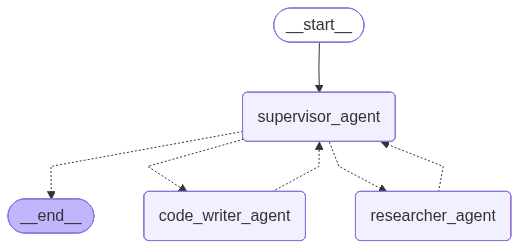

In [154]:
app=graph.compile()
app

In [140]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("----")

below my goto*****   *****************************
code_writer_agent
((), {'supervisor_agent': {'next': 'code_writer_agent'}})
----
(('code_writer_agent:f09ef969-7ca9-8fb2-9a85-d679dc57f2d5',), {'model': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'functions.python_repl_tool:0', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 138, 'total_tokens': 164, 'completion_time': 0.064286409, 'completion_tokens_details': None, 'prompt_time': 0.016866818, 'prompt_tokens_details': None, 'queue_time': 0.276770611, 'total_time': 0.081153227}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_241bc7119c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4f23-2425-7230-b94b-43ea9a9f4a4b-0', tool_calls=[{'name': 'python_repl_to

In [128]:
result = app.invoke({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True)

below my goto*****   *****************************
researcher_agent
below my goto*****   *****************************
code_writer_agent
below my goto*****   *****************************
FINISH


In [136]:
for i in result['messages']:
    i.pretty_print()

================================ Human Message =================================

What's the square root of 42?
================================ Human Message =================================
Name: researcher_agent

I can’t compute square roots myself, but a quick check shows that √42 is approximately 6.4807.
================================ Human Message =================================
Name: code_writer_agent

6.48074069840786


In [138]:
def print_messages(question):
    result = app.invoke({"messages": [("user", question)]}, subgraphs=True)
    for i in result['messages']:
        i.pretty_print()

In [139]:
print_messages("Find the sum of numbers from 1 to 500")

below my goto*****   *****************************
code_writer_agent
below my goto*****   *****************************
FINISH
================================ Human Message =================================

Find the sum of numbers from 1 to 500
================================ Human Message =================================
Name: code_writer_agent

125250


In [141]:
print_messages("Find the current CEO of Google. Then compute the number of characters in his name and calculate its cube.")

below my goto*****   *****************************
researcher_agent
below my goto*****   *****************************
code_writer_agent
below my goto*****   *****************************
FINISH
================================ Human Message =================================

Find the current CEO of Google. Then compute the number of characters in his name and calculate its cube.
================================ Human Message =================================
Name: researcher_agent

Based on my research, the current CEO of Google is **Sundar Pichai**. He has been the CEO of Google since August 2015 and also became the CEO of Alphabet (Google's parent company) in December 2019.

As for the mathematical calculations you requested - counting the characters in his name and computing its cube - I'm not able to perform calculations or write code per my instructions. However, I can provide you with the information I found so you can do those calculations yourself if needed.
==================

In [155]:
print_messages("Who is the CEO of Tesla? Reverse his name, count the number of consonants in the reversed name, square that number, and finally explain what Tesla is known for.")

below my goto*****   *****************************
researcher_agent
below my goto*****   *****************************
code_writer_agent
below my goto*****   *****************************
FINISH
================================ Human Message =================================

Who is the CEO of Tesla? Reverse his name, count the number of consonants in the reversed name, square that number, and finally explain what Tesla is known for.
================================ Human Message =================================
Name: researcher_agent

Based on my search, here are the factual findings:

**CEO of Tesla:** Elon Musk

**What Tesla is known for:**
Tesla is an American multinational automotive and clean energy company that is primarily known for:

1. **Electric Vehicles** - Tesla is credited with pioneering and popularizing electric cars, making them mainstream through models like the Model S, Model 3, Model X, Model Y, and the upcoming Cybertruck

2. **Battery Technology** - The company d